In [1]:
import sys
sys.path.append('.')
# from configs import path, nit, threedigits, thresh
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
import math
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pblim = 0.06

dx=4
dy=4


deltax = 10
deltay = 10
deltaxy = 7


Stokes = [
        'I',
        'Q',
        'U'
        ]

manual_setting=1

In [3]:
def ra_dec_to_degrees(ra, dec):
    ra = ra.split(':')
    ra_hours = int(ra[0])
    ra_minutes = int(ra[1])
    ra_seconds = int(ra[2])

    dec = dec.split(':')
    dec_degrees = int(dec[0])
    dec_minutes = int(dec[1])
    dec_seconds = int(dec[2])
    # Convert RA to degrees
    ra_degrees = (ra_hours + ra_minutes / 60 + ra_seconds / 3600) * 15

    # Convert Dec to degrees
    sign = 1 if dec_degrees >= 0 else -1
    dec_degrees = abs(dec_degrees) + dec_minutes / 60 + dec_seconds / 3600
    dec_degrees *= sign

    return ra_degrees, dec_degrees

In [4]:
if manual_setting == 1:
    ra_list = ['3:31:54', '3:34:16', '3:33:21', '3:35:05', '3:31:19', '3:30:09', '3:28:40', '3:32:41', '3:34:01']
    dec_list = ['31:04:39', '31:12:10', '30:55:28', '30:47:04', '30:47:23', '30:32:53', '30:49:56', '30:20:11', '31:18:40']

    ra_list = np.array(ra_list)
    dec_list = np.array(dec_list)

    RA0=[]
    DEC0=[]
    for i in range(ra_list.shape[0]):
        radec=ra_dec_to_degrees(ra_list[i], dec_list[i])
        RA0.append(radec[0])
        DEC0.append(radec[1])


elif manual_setting == 0:   

    imagename= threedigits + '-mosaic-fieldALL-Stokes'+str(Stoke)+'-2.5arc-'+str(nit)+'-'+str(thresh)+'-spwALL-pb'+str(pblim)+'-cyclenit500'

    catalog_name= path +'/Images/'+ imagename + '.image.pybdsf.srl'

    df = pd.read_csv(catalog_name, delim_whitespace=True)

    RA0 = df['RA'].tolist()
    DEC0 = df['DEC'].tolist()

In [5]:
stokes = 'Q'

In [6]:
fits_file ='../server/StokesQ.fits'

/var/folders/l1/vk05brrd5vgg5rxsglsqwbjh0000gn/T/ipykernel_1741/574806446.py:15: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Intensity')


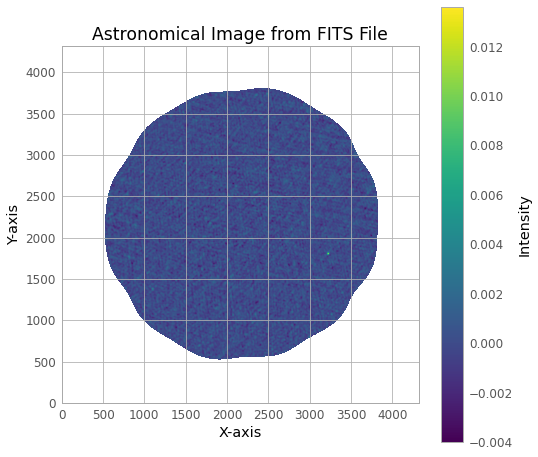

In [7]:
from astropy.visualization import astropy_mpl_style, imshow_norm
import matplotlib.pyplot as plt

# Use the astropy_mpl_style for a nicer plot
plt.style.use(astropy_mpl_style)

# Open the FITS file
with fits.open(fits_file) as hdul:
    # Access the image data
    data = hdul[0].data[0,:,:]

    # Display the image using matplotlib
    plt.figure(figsize=(8, 8))
    plt.imshow(data, cmap='viridis', origin='lower')
    plt.colorbar(label='Intensity')
    plt.title('Astronomical Image from FITS File')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.show()

In [8]:
hdulist=fits.open(fits_file)

In [9]:
hdulist

In [10]:
img=hdulist[0].data

In [11]:
print(img[0])

[[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


In [12]:
img.shape

(95, 4320, 4320)

In [13]:
img[0,:,:]

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)

In [14]:
wcs=WCS(hdulist[0].header)

Set OBSGEO-B to    34.078827 from OBSGEO-[XYZ].
Set OBSGEO-H to     2115.607 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [15]:
wcs

WCS Keywords

Number of WCS axes: 4
CTYPE : 'RA---SIN'  'DEC--SIN'  'FREQ'  'STOKES'  
CRVAL : 53.01887500417  31.08444444444  1333673220.556  2.0  
CRPIX : 2161.0  2161.0  1.0  1.0  
PC1_1 PC1_2 PC1_3 PC1_4  : 1.0  0.0  0.0  0.0  
PC2_1 PC2_2 PC2_3 PC2_4  : 0.0  1.0  0.0  0.0  
PC3_1 PC3_2 PC3_3 PC3_4  : 0.0  0.0  1.0  0.0  
PC4_1 PC4_2 PC4_3 PC4_4  : 0.0  0.0  0.0  1.0  
CDELT : -0.0006944444444444  0.0006944444444444  8003883.544893  1.0  
NAXIS : 4320  4320  95

In [16]:
stok=2

In [17]:
for ip in range(len(RA0)):
    print(ip)

0
1
2
3
4
5
6
7
8


In [18]:
ip=0

In [19]:
sky1=[[RA0[ip],DEC0[ip],1.47339395E9,0]]

In [20]:
sky1

[[52.975, 31.0775, 1473393950.0, 0]]

In [21]:
pixcrd2 = wcs.all_world2pix(sky1, 0)

In [22]:
pixcrd2

array([[ 2.21411177e+03,  2.15001070e+03,  1.74566170e+01,
        -2.00000000e+00]])

In [23]:
x0=int(pixcrd2[0][0]+0.5)

In [24]:
print(x0)

2214


In [25]:
y0=int(pixcrd2[0][1]+0.5)

In [26]:
y0

2150

In [27]:
DEC0[ip]

31.0775

In [28]:
if (DEC0[ip]>=0):
    sourcename_RADEC="H%07.3f+%06.3f"  % (int(1.E3*RA0[ip])/1000.,int(1.E3*DEC0[ip])/1000.)
else:  
    sourcename_RADEC="H%07.3f%06.3f"  % (int(1.E3*RA0[ip])/1000.,int(1.E3*DEC0[ip])/1000.)

In [29]:
sourcename_RADEC

'H052.975+31.077'

In [30]:
spectrum_file = "%s_%s_%s_%s.pro" % (sourcename_RADEC, dx, dy, stokes)

In [31]:
spectrum_file

'H052.975+31.077_4_4_Q.pro'

In [32]:
OUT=open('../server/'+spectrum_file,"w")

In [33]:
OUT

<_io.TextIOWrapper name='../server/H052.975+31.077_4_4_Q.pro' mode='w' encoding='UTF-8'>

In [34]:
print("Pixel coordinates: ",x0,y0,sourcename_RADEC,spectrum_file)

Pixel coordinates:  2214 2150 H052.975+31.077 H052.975+31.077_4_4_Q.pro


In [35]:
print("## RA DEC: ",RA0[ip],DEC0[ip], file=OUT)

In [36]:
print("## Pixel coordinates: ",x0,y0,"  Box : %d  %d" % (dx,dy), file=OUT)

In [37]:
print("## Source name: ",sourcename_RADEC," Stokes ",stokes, file=OUT)

In [38]:
print("## Spectrum file: ",spectrum_file, file=OUT)

In [39]:
print("##  ", file=OUT)

In [40]:
box_spectrum=img[:,(y0-dy):(y0+dy),(x0-dx):(x0+dx)]

In [41]:
box_spectrum.shape

(95, 8, 8)

In [42]:
img[:,x0, (0)]

array([   nan,    nan, 1.e+30, 1.e+30, 1.e+30, 1.e+30, 1.e+30, 1.e+30,
       1.e+30, 1.e+30, 1.e+30,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan, 1.e+30,
       1.e+30, 1.e+30, 1.e+30, 1.e+30, 1.e+30, 1.e+30, 1.e+30, 1.e+30,
       1.e+30, 1.e+30, 1.e+30, 1.e+30, 1.e+30, 1.e+30, 1.e+30,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan,    nan,
          nan,    nan,    nan,    nan,    nan,    nan, 1.e+30, 1.e+30,
       1.e+30, 1.e+30, 1.e+30, 1.e+30, 1.e+30, 1.e+30, 1.e+30,    nan,
          nan,    nan,    nan,    nan,    nan,    nan,    nan],
      dtype=float32)

In [43]:
mean_spectrum=img[:,x0,y0]

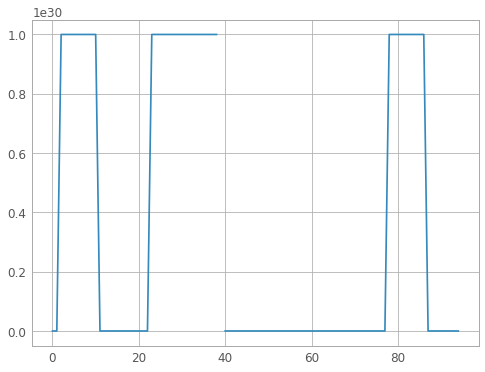

In [44]:
plt.plot(mean_spectrum)

In [45]:
mean_spectrum

array([ 1.08772435e-03,  1.08772435e-03,  1.00000002e+30,  1.00000002e+30,
        1.00000002e+30,  1.00000002e+30,  1.00000002e+30,  1.00000002e+30,
        1.00000002e+30,  1.00000002e+30,  1.00000002e+30,  2.54143873e-04,
        4.97473520e-04,  2.67752563e-04,  6.13405791e-05,  1.03490733e-04,
        2.63288384e-04, -1.24657367e-04, -3.19238789e-05,  2.81579123e-04,
        2.20408052e-04,  2.52033497e-04, -3.40041937e-04,  1.00000002e+30,
        1.00000002e+30,  1.00000002e+30,  1.00000002e+30,  1.00000002e+30,
        1.00000002e+30,  1.00000002e+30,  1.00000002e+30,  1.00000002e+30,
        1.00000002e+30,  1.00000002e+30,  1.00000002e+30,  1.00000002e+30,
        1.00000002e+30,  1.00000002e+30,  1.00000002e+30,             nan,
        3.19459476e-04, -6.56241464e-05, -2.78072025e-06,  9.37277509e-05,
       -1.06451102e-04, -8.54701011e-06, -6.27921312e-04,  1.00293919e-03,
        3.67554865e-04, -1.16103831e-04, -1.21525118e-04,  1.92466599e-04,
       -1.59223462e-04, -

In [46]:
freq=np.copy(mean_spectrum)

In [47]:
freq

array([ 1.08772435e-03,  1.08772435e-03,  1.00000002e+30,  1.00000002e+30,
        1.00000002e+30,  1.00000002e+30,  1.00000002e+30,  1.00000002e+30,
        1.00000002e+30,  1.00000002e+30,  1.00000002e+30,  2.54143873e-04,
        4.97473520e-04,  2.67752563e-04,  6.13405791e-05,  1.03490733e-04,
        2.63288384e-04, -1.24657367e-04, -3.19238789e-05,  2.81579123e-04,
        2.20408052e-04,  2.52033497e-04, -3.40041937e-04,  1.00000002e+30,
        1.00000002e+30,  1.00000002e+30,  1.00000002e+30,  1.00000002e+30,
        1.00000002e+30,  1.00000002e+30,  1.00000002e+30,  1.00000002e+30,
        1.00000002e+30,  1.00000002e+30,  1.00000002e+30,  1.00000002e+30,
        1.00000002e+30,  1.00000002e+30,  1.00000002e+30,             nan,
        3.19459476e-04, -6.56241464e-05, -2.78072025e-06,  9.37277509e-05,
       -1.06451102e-04, -8.54701011e-06, -6.27921312e-04,  1.00293919e-03,
        3.67554865e-04, -1.16103831e-04, -1.21525118e-04,  1.92466599e-04,
       -1.59223462e-04, -

In [48]:
flag=np.copy(mean_spectrum)*0.0

In [49]:
flag

array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0., -0., -0.,  0.,  0.,  0., -0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
       nan,  0., -0., -0.,  0., -0., -0., -0.,  0.,  0., -0., -0.,  0.,
       -0., -0., -0.,  0.,  0.,  0.,  0., -0., -0.,  0.,  0.,  0.,  0.,
        0.,  0., -0.,  0.,  0., -0.,  0., -0.,  0.,  0., -0.,  0., -0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
       -0., -0.,  0.,  0.], dtype=float32)

In [50]:
flag[np.isnan(flag)]=0.0

In [51]:
flag

array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0., -0., -0.,  0.,  0.,  0., -0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0., -0., -0.,  0., -0., -0., -0.,  0.,  0., -0., -0.,  0.,
       -0., -0., -0.,  0.,  0.,  0.,  0., -0., -0.,  0.,  0.,  0.,  0.,
        0.,  0., -0.,  0.,  0., -0.,  0., -0.,  0.,  0., -0.,  0., -0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
       -0., -0.,  0.,  0.], dtype=float32)

In [52]:
len(mean_spectrum)

95

In [53]:
sky=wcs.all_pix2world([[x0,y0,0,stok]],4)

In [54]:
sky

array([[5.29783351e+01, 3.10747159e+01, 1.30165769e+09, 0.00000000e+00]])

In [55]:
freq[0]=sky[0][2]

In [56]:
freq[0]

1301657700.0

In [57]:
mean_spectrum[0]=np.average(box_spectrum[0,:,:])

In [58]:
mean_spectrum[0]

0.0002980854

In [59]:
box_spectrum.shape

(95, 8, 8)

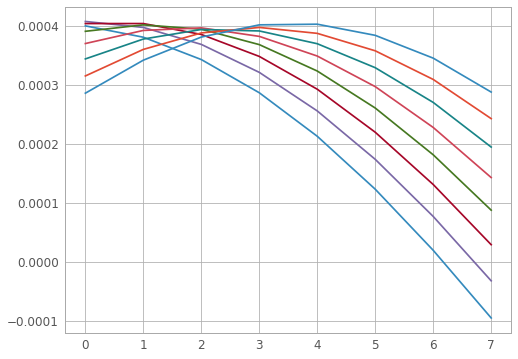

In [60]:
plt.plot(box_spectrum[0])

In [61]:
deltax = 10
deltay = 10
deltaxy = 7

background_1 = img[0,y0, (x0+deltay)]
background_2 = img[0,y0, (x0-deltay)]
background_3 = img[0,(y0+deltax), x0]
background_4 = img[0,(y0-deltax), x0]
background_5 = img[0,(y0+deltax), (x0+deltay)]
background_6 = img[0,(y0+deltax), (x0-deltay)]
background_7 = img[0,(y0-deltax), (x0-deltay)]
background_8 = img[0,(y0-deltax), (x0+deltay)]

In [62]:
print (f"Backgrounds:{background_1},{background_2},{background_3},{background_4},{background_5},{background_6},{background_7},{background_8}")

Backgrounds:0.000535417755600065,-0.00013363032485358417,-0.0006522774347104132,-2.1610214389511384e-05,-9.478274296270683e-05,-0.0010166040156036615,9.401832357980311e-05,-0.0005533327348530293


In [63]:
mean_spectrum[0]

0.0002980854

In [64]:
diff = mean_spectrum[0]-[background_1,background_2,background_3,background_4,
        background_5,background_6,background_7,background_8]

In [65]:
diff

array([-0.00023733,  0.00043172,  0.00095036,  0.0003197 ,  0.00039287,
        0.00131469,  0.00020407,  0.00085142], dtype=float32)

In [66]:
np.mean(diff)

0.0005284356

In [67]:
if (mean_spectrum[0]>1.E10):
    # If in here, found at least some pixels with BLANK vale 1.E30
    # Discard the whole channel. Set flag array value to 1.
    mean_spectrum[0]=0
    flag[ispec]=1.
    print("%15.12e  %15.8e  %d" % (freq[ispec],mean_spectrum[ispec],int(flag[ispec]+0.5)), file=OUT)

In [68]:
ispec=0
for ispec in range(len(mean_spectrum)):
    # Get ferquency of channel:
    # I have to change th 4th index
    sky=wcs.all_pix2world([[x0,y0,ispec,stok]],0)
    freq[ispec]=sky[0][2]

    # Average over the box:
    mean_spectrum[ispec]=np.average(box_spectrum[ispec,:,:])
    if (mean_spectrum[ispec]>1.E10):
        # If in here, found at least some pixels with BLANK vale 1.E30
        # Discard the whole channel. Set flag array value to 1.
        mean_spectrum[ispec]=0
        flag[ispec]=1.
    print("%15.12e  %15.8e  %d" % (freq[ispec],mean_spectrum[ispec],int(flag[ispec]+0.5)), file=OUT)

In [69]:
OUT.close()

In [159]:
import sys
sys.path.append('.')
# from configs import path, nit, threedigits, thresh
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
import math
import pandas as pd

pblim = 0.06

dx=4
dy=4


deltax = 15
deltay = 15
deltaxy = 12


Stokes = [

        'Q'

        ]

manual_setting=1


def ra_dec_to_degrees(ra, dec):
    ra = ra.split(':')
    ra_hours = int(ra[0])
    ra_minutes = int(ra[1])
    ra_seconds = int(ra[2])

    dec = dec.split(':')
    dec_degrees = int(dec[0])
    dec_minutes = int(dec[1])
    dec_seconds = int(dec[2])
    # Convert RA to degrees
    ra_degrees = (ra_hours + ra_minutes / 60 + ra_seconds / 3600) * 15

    # Convert Dec to degrees
    sign = 1 if dec_degrees >= 0 else -1
    dec_degrees = abs(dec_degrees) + dec_minutes / 60 + dec_seconds / 3600
    dec_degrees *= sign

    return ra_degrees, dec_degrees

#----------------------------------------------------------------
if manual_setting == 1:
#     ra_list = ['3:31:54', '3:34:16', '3:33:21', '3:35:05', '3:31:19', '3:30:09', '3:28:40', '3:32:41', '3:34:01']
#     dec_list = ['31:04:39', '31:12:10', '30:55:28', '30:47:04', '30:47:23', '30:32:53', '30:49:56', '30:20:11', '31:18:40']

    ra_list = ['3:30:24']
    dec_list = ['31:47:07']
    ra_list = np.array(ra_list)
    dec_list = np.array(dec_list)

    RA0=[]
    DEC0=[]
    for i in range(ra_list.shape[0]):
        radec=ra_dec_to_degrees(ra_list[i], dec_list[i])
        RA0.append(radec[0])
        DEC0.append(radec[1])


elif manual_setting == 0:   

    imagename= threedigits + '-mosaic-fieldALL-Stokes'+str(Stoke)+'-2.5arc-'+str(nit)+'-'+str(thresh)+'-spwALL-pb'+str(pblim)+'-cyclenit500'

    catalog_name= path +'/Images/'+ imagename + '.image.pybdsf.srl'

    df = pd.read_csv(catalog_name, delim_whitespace=True)

    RA0 = df['RA'].tolist()
    DEC0 = df['DEC'].tolist()
#----------------------------------------------------------------
for stokes in Stokes:
    
    fits_file ='../server/'+'/Stokes'+stokes+'.fits'
    hdulist=fits.open(fits_file)
    img=hdulist[0].data
    wcs=WCS(hdulist[0].header)
    
    if stokes=='I':
        stok = 1
    if stokes=='Q':
        stok = 2
    if stokes=='U':
        stok = 3        

    for ip in range(len(RA0)):
        sky1=[[RA0[ip],DEC0[ip],1.47339395E9,0]]
        pixcrd2 = wcs.all_world2pix(sky1, 0) 
        print(pixcrd2)

        x0=int(pixcrd2[0][0]+0.5)
        y0=int(pixcrd2[0][1]+0.5)

        if (DEC0[ip]>=0):
            sourcename_RADEC="H%07.3f+%06.3f"  % (int(1.E3*RA0[ip])/1000.,int(1.E3*DEC0[ip])/1000.)
        else:  
            sourcename_RADEC="H%07.3f%06.3f"  % (int(1.E3*RA0[ip])/1000.,int(1.E3*DEC0[ip])/1000.)

        spectrum_file = "%s_%s_%s_%s.pro" % (sourcename_RADEC, dx, dy, stokes)

        OUT=open('../server/'+spectrum_file,"w")

        print("Pixel coordinates: ",x0,y0,sourcename_RADEC,spectrum_file)
        print("## RA DEC: ",RA0[ip],DEC0[ip], file=OUT)
        print("## Pixel coordinates: ",x0,y0,"  Box : %d  %d" % (dx,dy), file=OUT)
        print("## Source name: ",sourcename_RADEC," Stokes ",stokes, file=OUT)
        print("## Spectrum file: ",spectrum_file, file=OUT)
        print("##  ", file=OUT)

        box_spectrum=img[:,(y0-dy):(y0+dy),(x0-dx):(x0+dx)]
        mean_spectrum=img[:,x0,y0]
        freq=np.copy(mean_spectrum)
        

        # Use the array flag to keep track of flagged channels
        flag=np.copy(mean_spectrum)*0.0

        flag[np.isnan(flag)]=0.0

       
        for ispec in range(len(mean_spectrum)):
            # Get ferquency of channel:
            # I have to change th 4th index
            sky=wcs.all_pix2world([[x0,y0,ispec,stok]],0)
            freq[ispec]=sky[0][2]

            # Average over the box:
            mean_spectrum[ispec]=np.average(box_spectrum[ispec,:,:])
            
            
            #Background
            background_1 = img[ispec,x0, (y0+deltay)]
            background_2 = img[ispec,x0, (y0-deltay)]
            background_3 = img[ispec,(x0+deltax), y0]
            background_4 = img[ispec,(x0-deltax), y0]
            background_5 = img[ispec,(x0+deltax), (y0+deltay)]
            background_6 = img[ispec,(x0+deltax), (y0-deltay)]
            background_7 = img[ispec,(x0-deltax), (y0-deltay)]
            background_8 = img[ispec,(x0-deltax), (y0+deltay)]
            print (f"Backgrounds:{background_1},{background_2},{background_3},{background_4},{background_5},{background_6},{background_7},{background_8}")
            
            diff = mean_spectrum[ispec]-[background_1,background_2,background_3,background_4,
                    background_5,background_6,background_7,background_8]
            
            mean_spectrum_reduced = np.median(diff)
            
            if (mean_spectrum[ispec]>1.E10):
                # If in here, found at least some pixels with BLANK vale 1.E30
                # Discard the whole channel. Set flag array value to 1.
                mean_spectrum[ispec]=0
                flag[ispec]=1.
            print("%15.12e  %15.8e  %d" % (freq[ispec],mean_spectrum_reduced,int(flag[ispec]+0.5)), file=OUT)


        OUT.close()

    rms=np.std(mean_spectrum)

    if (rms>0.002):
        print(sourcename_RADEC, rms)

[[ 2.67271537e+03  3.17014247e+03  1.94333024e+01 -2.00000000e+00]]
Pixel coordinates:  2673 3170 H052.600+31.785 H052.600+31.785_4_4_Q.pro
Backgrounds:0.00028339322307147086,0.0003153853176627308,0.00033478660043329,0.00033556405105628073,0.0003056271525565535,0.00017661339370533824,0.0004041320935357362,0.0002931867493316531
Backgrounds:0.00028339322307147086,0.0003153853176627308,0.00033478660043329,0.00033556405105628073,0.0003056271525565535,0.00017661339370533824,0.0004041320935357362,0.0002931867493316531
Backgrounds:0.00026851106667891145,0.0001245883177034557,0.00019372782844584435,0.0003424648311920464,-8.409831025346648e-06,0.00016125118418131024,0.0005971898208372295,0.0003831449430435896
Backgrounds:0.000824163609649986,5.0574453780427575e-05,0.00015425868332386017,0.0003835568786598742,0.0004884846857748926,0.00023380776110570878,0.00021134332928340882,0.0008105066372081637
Backgrounds:0.00029763486236333847,0.0001931352453539148,0.0001340668386546895,0.000446205754997208

In [155]:
import sys
sys.path.append('.')
# from configs import path, nit
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
import math

dx=4
dy=4
manual_setting=1
Stokes = [

        'Q'
        ]


def ra_dec_to_degrees(ra, dec):
    ra = ra.split(':')
    ra_hours = int(ra[0])
    ra_minutes = int(ra[1])
    ra_seconds = int(ra[2])

    dec = dec.split(':')
    dec_degrees = int(dec[0])
    dec_minutes = int(dec[1])
    dec_seconds = int(dec[2])
    # Convert RA to degrees
    ra_degrees = (ra_hours + ra_minutes / 60 + ra_seconds / 3600) * 15

    # Convert Dec to degrees
    sign = 1 if dec_degrees >= 0 else -1
    dec_degrees = abs(dec_degrees) + dec_minutes / 60 + dec_seconds / 3600
    dec_degrees *= sign

    return ra_degrees, dec_degrees

# ra_list = ['3:31:54', '3:34:16', '3:33:21', '3:35:05', '3:31:19', '3:30:09', '3:28:40', '3:32:41', '3:34:01']
# dec_list = ['31:04:39', '31:12:10', '30:55:28', '30:47:04', '30:47:23', '30:32:53', '30:49:56', '30:20:11', '31:18:40']

ra_list = ['3:30:24']
dec_list = ['31:47:07']

ra_list = np.array(ra_list)
dec_list = np.array(dec_list)

RA=[]
DEC=[]
for i in range(ra_list.shape[0]):
    radec=ra_dec_to_degrees(ra_list[i], dec_list[i])
    RA.append(radec[0])
    DEC.append(radec[1])

print(RA)
print(DEC)

if manual_setting!=0:
    RA0=RA
    DEC0=DEC
else:
    with open("source_list_test_G17.dat", 'r') as SOURCES:
        RA0=np.double(SOURCES[1])
        DEC0=np.double(SOURCES[2])

for stokes in Stokes:
    fits_file = '../server/'+'/Stokes'+stokes+'.fits'
    hdulist=fits.open(fits_file)
    img=hdulist[0].data
    wcs=WCS(hdulist[0].header)
    if stokes=='I':
        stok = 1
    if stokes=='Q':
        stok = 2
    if stokes=='U':
        stoke = 3        

    for ip in range(len(RA0)):
        sky1=[[RA0[ip],DEC0[ip],1.47339395E9,0]]
        pixcrd2 = wcs.all_world2pix(sky1, 0) 
        print(pixcrd2)

        x0=int(pixcrd2[0][0]+0.5)
        y0=int(pixcrd2[0][1]+0.5)

        if (DEC0[ip]>=0):
            sourcename_RADEC="J%07.3f+%06.3f"  % (int(1.E3*RA0[ip])/1000.,int(1.E3*DEC0[ip])/1000.)
        else:  
            sourcename_RADEC="J%07.3f%06.3f"  % (int(1.E3*RA0[ip])/1000.,int(1.E3*DEC0[ip])/1000.)

        spectrum_file="%s_box_%03d_%03d_%s.pro" % (sourcename_RADEC,dx,dy,stokes)

        OUT=open('../server/'+spectrum_file,"w")

        print("Pixel coordinates: ",x0,y0,sourcename_RADEC,spectrum_file)

        print("## RA DEC: ",RA0[ip],DEC0[ip], file=OUT)
        print("## Pixel coordinates: ",x0,y0,"  Box : %d  %d" % (dx,dy), file=OUT)
        print("## Source name: ",sourcename_RADEC," Stokes ",stokes, file=OUT)
        print("## Spectrum file: ",spectrum_file, file=OUT)
        print("##  ", file=OUT)

        box_spectrum=img[:,(y0-dy):(y0+dy),(x0-dx):(x0+dx)]
        mean_spectrum=img[:,x0,y0]
        freq=np.copy(mean_spectrum)

        # Use the array flag to keep track of flagged channels
        flag=np.copy(mean_spectrum)*0.0

        flag[np.isnan(flag)]=0.0

        ispec=0
        for ispec in range(len(mean_spectrum)):
            # Get ferquency of channel:
            # I have to change th 4th index
            sky=wcs.all_pix2world([[x0,y0,ispec,stok]],0)
            freq[ispec]=sky[0][2]

            # Average over the box:
            mean_spectrum[ispec]=np.average(box_spectrum[ispec,:,:])
            if (mean_spectrum[ispec]>1.E10):
                # If in here, found at least some pixels with BLANK vale 1.E30
                # Discard the whole channel. Set flag array value to 1.
                mean_spectrum[ispec]=0
                flag[ispec]=1.
            print("%15.12e  %15.8e  %d" % (freq[ispec],mean_spectrum[ispec],int(flag[ispec]+0.5)), file=OUT)


        OUT.close()

    rms=np.std(mean_spectrum)

    if (rms>0.002):
        print(sourcename_RADEC, rms)

[52.6]
[31.78527777777778]
[[ 2.67271537e+03  3.17014247e+03  1.94333024e+01 -2.00000000e+00]]
Pixel coordinates:  2673 3170 J052.600+31.785 J052.600+31.785_box_004_004_Q.pro


In [3]:


def setup_columns(pro_file,lines_to_skip=5):
    with open (pro_file, 'r') as file:
        lines = file.read().splitlines()[lines_to_skip:]
        lines = [ 
           [l.strip() for l in line.split()]
           for line in lines
        ]
        lines = np.array(lines).transpose()
        
        freq = np.double(lines[0])
        print(f"freq shape: {freq.shape}")
        flux = np.double(lines[1])
        print(f"flux shape: {flux.shape}")
    return(freq, flux)

In [4]:
original = setup_columns('../server/J053.504+31.311_box_004_004_Q.pro')
reduced_median = setup_columns('../server/median/H053.504+31.311_4_4_Q.pro')
reduced_mean = setup_columns('../server/mean/H053.504+31.311_4_4_Q.pro')

freq shape: (70,)
flux shape: (70,)
freq shape: (70,)
flux shape: (70,)
freq shape: (70,)
flux shape: (70,)


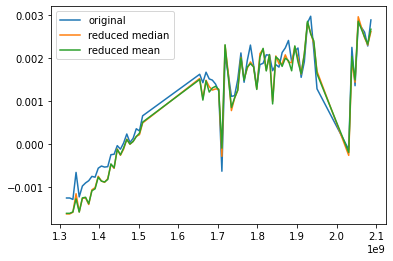

In [5]:
plt.figure
plt.plot(original[0], original[1], label = 'original')
plt.plot(reduced_median[0], reduced_median[1], label = 'reduced median')
plt.plot(reduced_mean[0], reduced_mean[1], label = 'reduced mean')
plt.legend()

In [6]:
original = setup_columns('../server/J052.600+31.785_box_004_004_Q.pro')
reduced_median = setup_columns('../server/median/H052.600+31.785_4_4_Q.pro')
reduced_mean = setup_columns('../server/mean/H052.600+31.785_4_4_Q.pro')

freq shape: (70,)
flux shape: (70,)
freq shape: (70,)
flux shape: (70,)
freq shape: (70,)
flux shape: (70,)


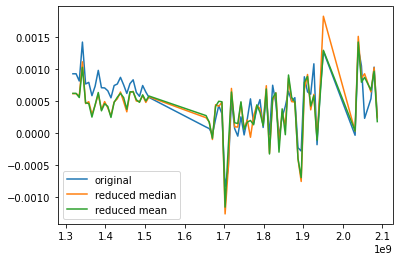

In [7]:
plt.figure
plt.plot(original[0], original[1], label = 'original')
plt.plot(reduced_median[0], reduced_median[1], label = 'reduced median')
plt.plot(reduced_mean[0], reduced_mean[1], label = 'reduced mean')
plt.legend()